# Bias, Variance, and the Trade-Off in Machine Learning

---

## Learning Contract

| Field | Value |
|---|---|
| **Topic** | Bias, Variance, and the Trade-Off in Machine Learning |
| **Target audience** | Python developers and aspiring data scientists with basic ML knowledge |
| **Depth** | Beginner-to-Intermediate |
| **Prerequisites** | Basic Python, introductory NumPy, basic Scikit-Learn (e.g. fitting a Linear Regression) |
| **Expected completion time** | 60–90 minutes |
| **Expected execution time** | Under 5 minutes (typically 60–120 seconds) |
| **Hardware** | CPU only — no GPU required |

### Learning Outcome

After completing this notebook you will be able to:

1. Explain bias and variance mathematically and intuitively.
2. Identify underfitting and overfitting from validation curves.
3. Compute an empirical bias-variance decomposition using repeated independent training experiments.
4. Use cross-validation on a development dataset to select model complexity and regularisation strength.
5. Evaluate a final model exactly once on a held-out test set.
6. Diagnose two critical failure modes in model selection.

### What Will Be Implemented

- Synthetic 1D regression dataset with a known true function
- Polynomial regression pipelines of varying complexity
- Repeated fitted-curve overlay (intuitive variability demonstration)
- Empirical bias-variance decomposition via M independent training experiments
- Cross-validation based degree selection
- Ridge regularisation with CV-based alpha selection
- Training data size experiment
- Two failure case demonstrations
- Final one-time evaluation on an untouched test set

---

## Section 2 — The Problem

Imagine you are building a model to predict house prices from neighbourhood features. You train it carefully, and it achieves an MSE of 2,100 on your training data. You deploy it. The MSE on new houses is 18,400.

You try a more complex model — a deep polynomial of the neighbourhood features. Training MSE drops to 150. Deployment MSE climbs to 47,000.

You try a simpler model — a single straight line through the data. Training MSE is 22,000. Deployment MSE is 22,500. Finally consistent — but consistently wrong.

**What is happening?**

The first two models learned the *training data* too well — including its noise — and failed to generalise. The third model was too simple to capture the real pattern at all.

These failure modes have precise names: **overfitting** (high variance) and **underfitting** (high bias). Understanding them — mathematically and practically — is what this notebook is about.

The naive approach — choose the model that scores best on the training data — seems reasonable. It works when the model's complexity is well matched to the data. It fails, often silently, at both extremes.

---

## Section 3 — Environment Setup

In [1]:
# Install dependencies if not already present
# Requires: numpy, matplotlib, scikit-learn
# Run this cell only if needed:
# !pip install numpy matplotlib scikit-learn

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sklearn
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
import warnings
import time
import os

warnings.filterwarnings('ignore')

print(f"numpy      : {np.__version__}")
print(f"matplotlib : {matplotlib.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

numpy      : 2.4.6
matplotlib : 3.10.9
scikit-learn: 1.9.0


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
# All experiment parameters are declared here as named constants.
# Change values here to reproduce the notebook with different settings.

RANDOM_SEED   = 42          # Master seed for development data and CV folds
TEST_SEED     = 999         # Independent seed for final test set generation

NOISE_STD     = 0.5         # Standard deviation of observation noise
X_MIN, X_MAX  = -3.0, 3.0  # Input domain

N_DEV         = 80          # Development dataset size
N_TEST        = 300         # Final test dataset size (generated once at the end)
N_EVAL        = 300         # Evaluation grid points for decomposition

DEGREES       = list(range(1, 13))   # Polynomial degrees to sweep (1–12)
N_CV_FOLDS    = 5                    # K in K-fold CV

M_BOOTSTRAP   = 200         # Independent training datasets for decomposition
DECOMP_DEGREES = [1, 2, 3, 4, 5, 6, 8, 10, 12]  # Subset used in decomposition

RIDGE_ALPHAS  = np.logspace(-3, 3, 25)  # Alpha sweep for regularisation
HIGH_DEGREE   = 12          # The deliberately complex model

SAMPLE_SIZES  = [20, 40, 80, 150, 300]  # Training sizes for size experiment
R_REPEATS     = 50          # Repetitions per sample size

# Asset output directories (relative to notebook location)
ASSETS_IMAGES   = os.path.join("..", "assets", "images")
ASSETS_DIAGRAMS = os.path.join("..", "assets", "diagrams")
os.makedirs(ASSETS_IMAGES, exist_ok=True)
os.makedirs(ASSETS_DIAGRAMS, exist_ok=True)

# Consistent colour palette
C_TRAIN    = "#2166ac"   # Blue   — training
C_VAL      = "#d6604d"   # Red-orange — validation / CV
C_TRUE     = "#1a1a1a"   # Near-black — true function
C_BIAS2    = "#d6604d"   # Red-orange — bias squared
C_VAR      = "#4dac26"   # Green  — variance
C_NOISE    = "#7b3294"   # Purple — irreducible noise
C_EXPECTED = "#e08214"   # Orange — expected error
C_PRED     = "#b2182b"   # Dark red — fitted predictions

print("Configuration loaded.")
print(f"  NOISE_STD = {NOISE_STD}  →  irreducible noise σ² = {NOISE_STD**2:.4f}")
print(f"  N_DEV = {N_DEV},  N_TEST = {N_TEST}")
print(f"  M_BOOTSTRAP = {M_BOOTSTRAP},  DECOMP_DEGREES = {DECOMP_DEGREES}")

Configuration loaded.
  NOISE_STD = 0.5  →  irreducible noise σ² = 0.2500
  N_DEV = 80,  N_TEST = 300
  M_BOOTSTRAP = 200,  DECOMP_DEGREES = [1, 2, 3, 4, 5, 6, 8, 10, 12]


---

## Section 4 — Explore the Input

We use a synthetic dataset generated from a known true function:

$$f(x) = \sin(1.5x), \quad x \in [-3, 3]$$

Each observation adds Gaussian noise:

$$y = f(x) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

Using a known true function is the key design choice: it lets us compute the **exact** irreducible noise floor ($\sigma^2$) and measure empirical bias and variance precisely against the known $f(x)$. This would be impossible with real data where the true function is unknown.

We generate **two independent datasets** from this same process:

- **Development dataset** (`X_dev`, `y_dev`): used for all model selection via cross-validation.
- **Final test set** (`X_test`, `y_test`): generated with an independent seed, locked away until Section 12, evaluated exactly once after all model-selection decisions are complete.

In [4]:
def true_function(x: np.ndarray) -> np.ndarray:
    """The known data-generating function f(x) = sin(1.5x)."""
    return np.sin(1.5 * x)


def generate_dataset(n: int, seed: int) -> tuple[np.ndarray, np.ndarray]:
    """Sample n observations from the DGP with the given seed."""
    rng = np.random.default_rng(seed)
    X = rng.uniform(X_MIN, X_MAX, n)
    y = true_function(X) + rng.normal(0, NOISE_STD, n)
    return X.reshape(-1, 1), y


# Development data — used for ALL model selection
X_dev, y_dev = generate_dataset(N_DEV, seed=RANDOM_SEED)

# Fixed evaluation grid — used for the bias-variance decomposition
X_eval = np.linspace(X_MIN, X_MAX, N_EVAL).reshape(-1, 1)
f_eval = true_function(X_eval.ravel())

print(f"Development dataset: X shape {X_dev.shape}, y shape {y_dev.shape}")
print(f"y_dev  — mean: {y_dev.mean():.3f}, std: {y_dev.std():.3f}, "
      f"min: {y_dev.min():.3f}, max: {y_dev.max():.3f}")
print(f"\nFinal test set is NOT generated yet — locked until Section 12.")

Development dataset: X shape (80, 1), y shape (80,)
y_dev  — mean: 0.016, std: 0.802, min: -1.739, max: 1.997

Final test set is NOT generated yet — locked until Section 12.


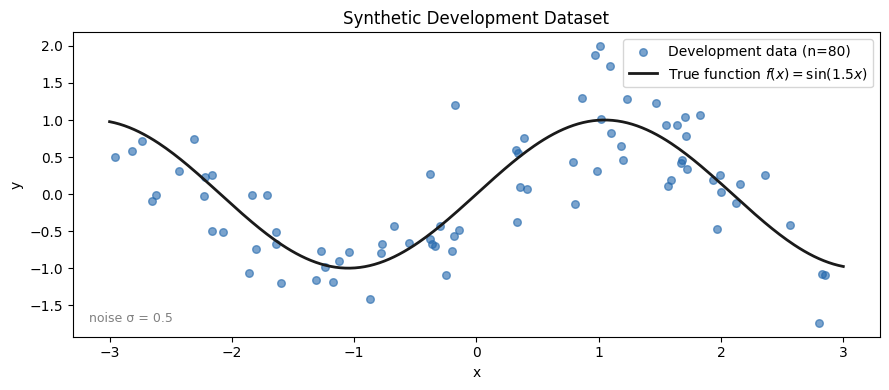

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(X_dev.ravel(), y_dev, s=30, alpha=0.6, color=C_TRAIN,
           label=f"Development data (n={N_DEV})")
ax.plot(X_eval.ravel(), f_eval, color=C_TRUE, lw=2,
        label=r"True function $f(x) = \sin(1.5x)$")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Synthetic Development Dataset")
ax.legend()
ax.annotate(f"noise σ = {NOISE_STD}", xy=(0.02, 0.05),
            xycoords="axes fraction", fontsize=9, color="grey")
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_IMAGES, "data_scatter.png"), dpi=150)
plt.show()


**What to notice:** The blue dots scatter around the smooth black curve. The gap between any point and the curve is noise — irreducible regardless of the model we choose. Our goal is to recover the black curve as accurately as possible given only the noisy blue dots.

---

## Section 5 — Build the Simplest Baseline

The simplest polynomial model is degree 1: a straight line. We fit it on the full development dataset to see what "too simple" looks like.

In [6]:
def make_poly_pipeline(degree: int, ridge_alpha: float = 0.0):
    """Create a polynomial regression pipeline.
    
    Uses Ridge when ridge_alpha > 0, LinearRegression otherwise.
    include_bias=False because sklearn pipelines add no intercept via
    PolynomialFeatures when the linear model handles it.
    """
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    if ridge_alpha > 0:
        regressor = Ridge(alpha=ridge_alpha)
    else:
        regressor = LinearRegression()
    return make_pipeline(poly, regressor)


# Fit degree-1 baseline on full development data
baseline = make_poly_pipeline(degree=1)
baseline.fit(X_dev, y_dev)

baseline_train_mse = mean_squared_error(y_dev, baseline.predict(X_dev))
print(f"Degree-1 baseline — training MSE: {baseline_train_mse:.4f}")
print()
print("The training MSE tells us how well the line fits the training points.")
print("It does NOT tell us whether the model generalises to new data.")

Degree-1 baseline — training MSE: 0.6037

The training MSE tells us how well the line fits the training points.
It does NOT tell us whether the model generalises to new data.


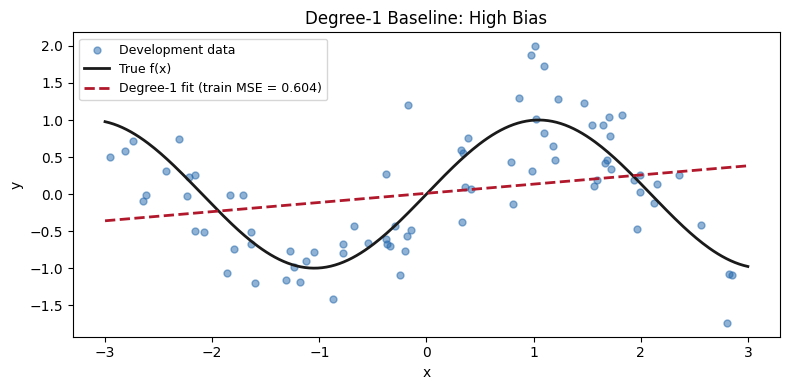


The straight line misses the curve's oscillations entirely.
It is systematically wrong — this is high bias / underfitting.


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X_dev.ravel(), y_dev, s=25, alpha=0.5, color=C_TRAIN,
           label="Development data")
ax.plot(X_eval.ravel(), f_eval, color=C_TRUE, lw=2, label="True f(x)")
ax.plot(X_eval.ravel(), baseline.predict(X_eval), color=C_PRED, lw=2,
        ls="--", label=f"Degree-1 fit (train MSE = {baseline_train_mse:.3f})")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Degree-1 Baseline: High Bias")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nThe straight line misses the curve's oscillations entirely.")
print("It is systematically wrong — this is high bias / underfitting.")

---

## Section 6 — Implement the Concept Step by Step

We now fit polynomial models of three complexity levels — low, medium, high — and observe how the fitted curve changes. These are fitted on the **full development dataset** to visualise the fitting behaviour. We record training MSE at each step.

Notice that training MSE always decreases as degree increases. This makes training MSE useless as a model-selection criterion — a lesson we will demonstrate rigorously in Section 9.

In [8]:
# Fit models at three complexity levels
showcase_degrees = [1, 4, 12]
showcase_models = {}
showcase_train_mse = {}

for d in showcase_degrees:
    model = make_poly_pipeline(degree=d)
    model.fit(X_dev, y_dev)
    showcase_models[d] = model
    showcase_train_mse[d] = mean_squared_error(y_dev, model.predict(X_dev))
    print(f"Degree {d:2d}  →  training MSE = {showcase_train_mse[d]:.4f}")

Degree  1  →  training MSE = 0.6037
Degree  4  →  training MSE = 0.2345
Degree 12  →  training MSE = 0.1897


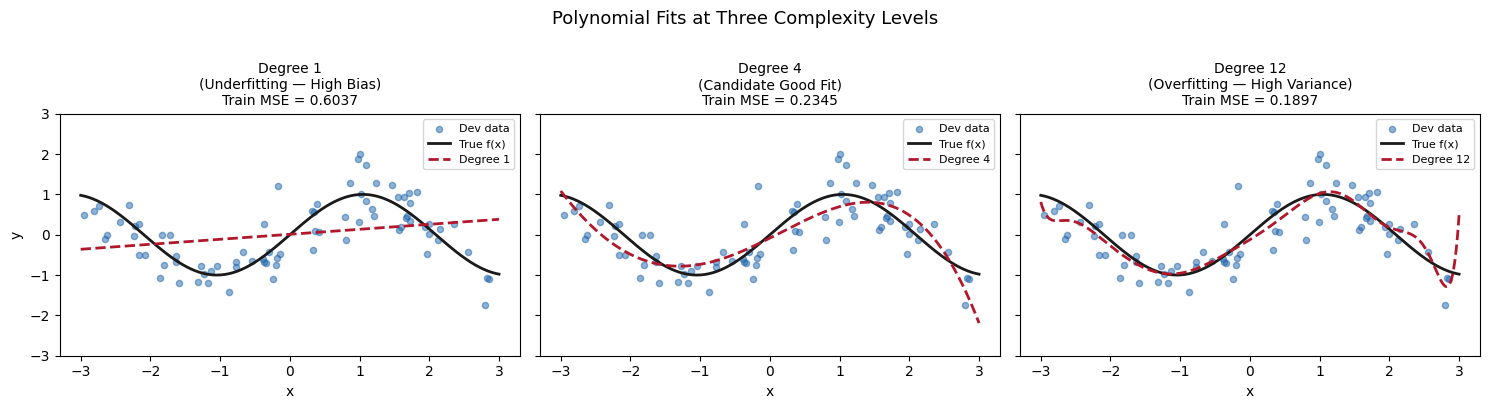

Saved: fit_comparison.png


In [9]:
titles = ["Degree 1\n(Underfitting — High Bias)",
          "Degree 4\n(Candidate Good Fit)",
          "Degree 12\n(Overfitting — High Variance)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, d, title in zip(axes, showcase_degrees, titles):
    ax.scatter(X_dev.ravel(), y_dev, s=20, alpha=0.5,
               color=C_TRAIN, label="Dev data")
    ax.plot(X_eval.ravel(), f_eval, color=C_TRUE, lw=2,
            label="True f(x)")
    ax.plot(X_eval.ravel(), showcase_models[d].predict(X_eval),
            color=C_PRED, lw=2, ls="--",
            label=f"Degree {d}")
    ax.set_title(f"{title}\nTrain MSE = {showcase_train_mse[d]:.4f}",
                 fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylim(-3, 3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("y")
fig.suptitle("Polynomial Fits at Three Complexity Levels",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_IMAGES, "fit_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fit_comparison.png")

**What to notice:**
- **Degree 1**: The line is too rigid to follow the curve. It is systematically wrong everywhere — high bias.
- **Degree 4**: The fit closely tracks the true function. Training MSE is higher than degree 12's, yet this is likely the better generalising model.
- **Degree 12**: The curve twists through the training points but wildly extrapolates in between — high variance. Training MSE is low, but predictions on new data would be poor.

Training MSE decreased monotonically from degree 1 to degree 12. Using training MSE alone for model selection would always select the most complex model.

---

## Section 7 — Visualise the Internal Mechanism

### The Bullseye Analogy

Before the mathematics, an analogy that builds intuition. Think of a model as an archer shooting at a target. Each arrow is one model trained on one dataset drawn from the same population.

> **This is an intuition-building analogy, not a mathematical definition.** Bias and variance have precise mathematical meanings defined in Section 8.

- **Bias**: How far, on average, does the archer land from the bullseye?
- **Variance**: How spread out are the arrows across shots?

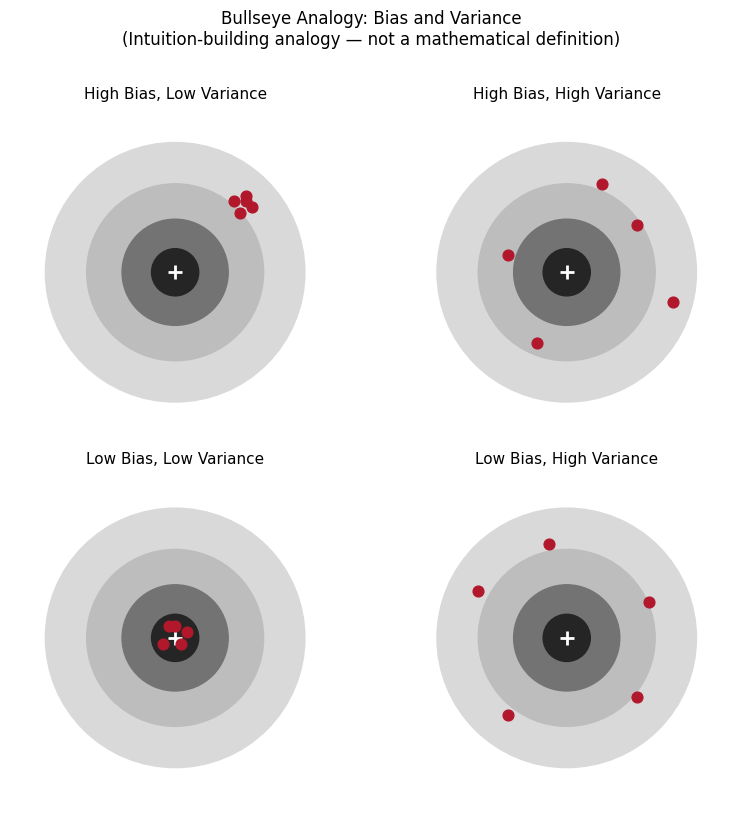

Saved: bullseye.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

quadrant_configs = [
    (axes[0, 0], "High Bias, Low Variance",
     [(1.2, 1.2), (1.1, 1.0), (1.3, 1.1), (1.2, 1.3), (1.0, 1.2)]),
    (axes[0, 1], "High Bias, High Variance",
     [(0.6, 1.5), (-1.0, 0.3), (1.8, -0.5), (-0.5, -1.2), (1.2, 0.8)]),
    (axes[1, 0], "Low Bias, Low Variance",
     [(0.1, -0.1), (-0.1, 0.2), (0.2, 0.1), (-0.2, -0.1), (0.0, 0.2)]),
    (axes[1, 1], "Low Bias, High Variance",
     [(-1.5, 0.8), (1.2, -1.0), (-0.3, 1.6), (1.4, 0.6), (-1.0, -1.3)]),
]

for ax, title, points in quadrant_configs:
    for r, color in [(2.2, "#d9d9d9"), (1.5, "#bdbdbd"),
                     (0.9, "#737373"), (0.4, "#252525")]:
        circle = plt.Circle((0, 0), r, color=color, fill=True)
        ax.add_patch(circle)
    ax.plot(0, 0, "w+", ms=10, mew=2)
    px, py = zip(*points)
    ax.scatter(px, py, color=C_PRED, s=60, zorder=5)
    ax.set_xlim(-2.8, 2.8); ax.set_ylim(-2.8, 2.8)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=11, pad=6)
    ax.axis("off")

fig.suptitle(
    "Bullseye Analogy: Bias and Variance\n"
    "(Intuition-building analogy — not a mathematical definition)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIAGRAMS, "bullseye.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bullseye.png")

### Repeated Fitted-Curve Overlay: Visualising Prediction Variability

We now generate 50 independent training datasets (each of size `N_DEV`) from the same DGP and fit both a low-complexity and a high-complexity model on each. We then plot all 50 fitted curves simultaneously.

This visualises **prediction variability** — how much the fitted model changes when the training data changes.

> **Important:** This overlay is an intuitive demonstration of how much predictions vary across training datasets. It is **not** the numerical bias-variance decomposition. The actual mathematical decomposition (computing Bias², Variance, and Expected Error as scalar quantities) is performed in Section 8.

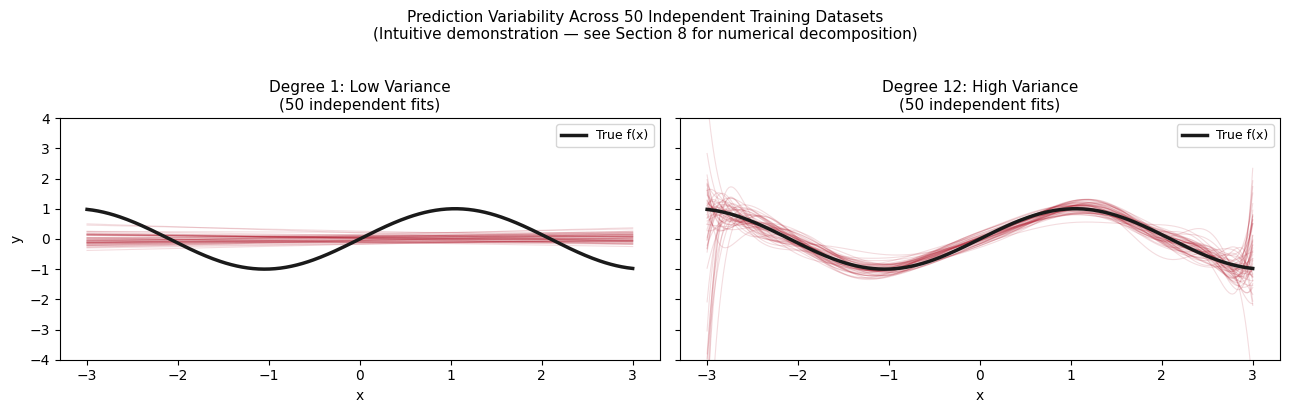

Saved: repeated_sampling.png


In [11]:
N_OVERLAY = 50  # Curves to overlay (visual only — not the full decomposition)
overlay_degrees = [1, 12]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, d in zip(axes, overlay_degrees):
    for m in range(N_OVERLAY):
        rng = np.random.default_rng(seed=1000 + m)
        X_m = rng.uniform(X_MIN, X_MAX, N_DEV).reshape(-1, 1)
        y_m = true_function(X_m.ravel()) + rng.normal(0, NOISE_STD, N_DEV)
        model_m = make_poly_pipeline(degree=d)
        model_m.fit(X_m, y_m)
        pred_m = model_m.predict(X_eval)
        ax.plot(X_eval.ravel(), pred_m, color=C_PRED,
                alpha=0.15, lw=0.8)

    ax.plot(X_eval.ravel(), f_eval, color=C_TRUE, lw=2.5, zorder=5,
            label="True f(x)")
    ax.set_title(
        f"Degree {d}: "
        f"{'Low' if d == 1 else 'High'} Variance\n"
        f"({N_OVERLAY} independent fits)",
        fontsize=11
    )
    ax.set_xlabel("x")
    ax.set_ylim(-4, 4)
    ax.legend(fontsize=9)

axes[0].set_ylabel("y")
fig.suptitle(
    "Prediction Variability Across 50 Independent Training Datasets\n"
    "(Intuitive demonstration — see Section 8 for numerical decomposition)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_IMAGES, "repeated_sampling.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: repeated_sampling.png")

**What to notice:**
- **Degree 1 (left)**: All 50 lines are similar. They are consistently biased — they miss the true curve in the same way regardless of which training dataset was used. Low variance, but high bias.
- **Degree 12 (right)**: The 50 curves vary wildly. Each training dataset produces a very different fitted model. The prediction at any point $x$ is highly sensitive to which training dataset was drawn. High variance.

---

## Section 8 — Mathematical Decomposition and Empirical Estimation

### The Mathematics

Let:
- $f(x)$ — the true, unknown data-generating function (known in our simulation)
- $\mathcal{D}$ — a training dataset of size $n$ drawn from the DGP
- $\hat{f}_{\mathcal{D}}(x)$ — the model trained on dataset $\mathcal{D}$, evaluated at $x$
- $\mathbb{E}_{\mathcal{D}}[\hat{f}_{\mathcal{D}}(x)]$ — the **expected prediction** at $x$, averaged over all possible training datasets of size $n$

The **bias** of the model at $x$ is:
$$\text{Bias}[\hat{f}(x)] = \mathbb{E}_{\mathcal{D}}[\hat{f}_{\mathcal{D}}(x)] - f(x)$$

This measures how far the average prediction is from the truth — the systematic error.

The **variance** of the model at $x$ is:
$$\text{Var}[\hat{f}(x)] = \mathbb{E}_{\mathcal{D}}\left[\left(\hat{f}_{\mathcal{D}}(x) - \mathbb{E}_{\mathcal{D}}[\hat{f}_{\mathcal{D}}(x)]\right)^2\right]$$

This measures how much predictions fluctuate when the training data changes.

For an observation $y = f(x) + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, \sigma^2)$, the **expected squared prediction error** decomposes exactly as:

$$\mathbb{E}\left[(y - \hat{f}_{\mathcal{D}}(x))^2\right] = \underbrace{\left(\text{Bias}[\hat{f}(x)]\right)^2}_{\text{Bias}^2} + \underbrace{\text{Var}[\hat{f}(x)]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible noise}}$$

The expectation is over both the randomness in the training data $\mathcal{D}$ and the noise $\varepsilon$ in new observations.

**Key points:**
1. **Bias²** and **Variance** depend on the model class and complexity. We can reduce them by changing the model.
2. **Irreducible noise** $\sigma^2$ depends only on the problem. No model can eliminate it.
3. The minimum expected error occurs where $\text{Bias}^2 + \text{Variance}$ is minimised — **not necessarily where Bias² = Variance**. The optimal trade-off depends on the specific magnitudes of how quickly each component changes with complexity.
4. The expectation $\mathbb{E}_{\mathcal{D}}[\cdot]$ is over **all possible training datasets** of size $n$ from the DGP. We approximate this by using $M$ independently generated training datasets.

### Connecting Math to Code

The `M_BOOTSTRAP = 200` independent training datasets we generate below directly approximate $\mathbb{E}_{\mathcal{D}}$. Each dataset produces one $\hat{f}_{\mathcal{D}}$. The mean of 200 predictions approximates $\mathbb{E}_{\mathcal{D}}[\hat{f}_{\mathcal{D}}(x)]$.

In [12]:
print("Running empirical bias-variance decomposition...")
print(f"  M = {M_BOOTSTRAP} independent training datasets")
print(f"  Degrees: {DECOMP_DEGREES}")
print(f"  Evaluation grid: {N_EVAL} points")
print()

t0 = time.time()

decomp_results = []

for d in DECOMP_DEGREES:
    # predictions[m, i] = prediction of model m at X_eval[i]
    predictions = np.empty((M_BOOTSTRAP, N_EVAL))

    for m in range(M_BOOTSTRAP):
        # Each training dataset uses its own independent seed
        rng = np.random.default_rng(seed=m)
        X_train_m = rng.uniform(X_MIN, X_MAX, N_DEV).reshape(-1, 1)
        y_train_m = true_function(X_train_m.ravel()) + \
                    rng.normal(0, NOISE_STD, N_DEV)

        model_m = make_poly_pipeline(degree=d)
        model_m.fit(X_train_m, y_train_m)
        predictions[m, :] = model_m.predict(X_eval)

    # Mean prediction across M training experiments
    mean_pred = predictions.mean(axis=0)   # shape: (N_EVAL,)

    # Integrated squared bias: mean over evaluation grid
    squared_bias = np.mean((mean_pred - f_eval) ** 2)

    # Integrated variance: mean of per-point prediction variance
    variance = np.mean(predictions.var(axis=0))

    # Irreducible noise: known from DGP
    noise = NOISE_STD ** 2

    # Expected prediction error estimate
    expected_error = squared_bias + variance + noise

    decomp_results.append({
        "degree": d,
        "bias2": squared_bias,
        "variance": variance,
        "noise": noise,
        "expected_error": expected_error,
    })

elapsed = time.time() - t0
print(f"Decomposition complete in {elapsed:.1f} seconds.")
print()
print(f"Note: These are empirical estimates from M={M_BOOTSTRAP} repeated")
print(f"training experiments. They approximate the theoretical quantities")
print(f"under the stated data-generating process (DGP).")

Running empirical bias-variance decomposition...
  M = 200 independent training datasets
  Degrees: [1, 2, 3, 4, 5, 6, 8, 10, 12]
  Evaluation grid: 300 points



Decomposition complete in 4.9 seconds.

Note: These are empirical estimates from M=200 repeated
training experiments. They approximate the theoretical quantities
under the stated data-generating process (DGP).


In [13]:
# Print the decomposition table
print(f"\nEmpirical Bias-Variance Decomposition (M={M_BOOTSTRAP} datasets, n={N_DEV} each)")
print(f"{'Degree':>6}  {'Bias²':>8}  {'Variance':>10}  {'Noise (σ²)':>11}  {'Exp. Error':>11}")
print("-" * 55)

min_exp_error = min(r["expected_error"] for r in decomp_results)
best_degree_decomp = next(r["degree"] for r in decomp_results
                          if r["expected_error"] == min_exp_error)

for r in decomp_results:
    marker = " ← min Expected Error" if r["degree"] == best_degree_decomp else ""
    print(f"{r['degree']:>6}  {r['bias2']:>8.4f}  {r['variance']:>10.4f}  "
          f"{r['noise']:>11.4f}  {r['expected_error']:>11.4f}{marker}")

print()
print(f"Irreducible noise floor σ² = {NOISE_STD**2:.4f} (fixed, from DGP)")
print(f"Degree with minimum empirical Expected Error: {best_degree_decomp}")


Empirical Bias-Variance Decomposition (M=200 datasets, n=80 each)
Degree     Bias²    Variance   Noise (σ²)   Exp. Error
-------------------------------------------------------
     1    0.4787      0.0179       0.2500       0.7466
     2    0.4788      0.0313       0.2500       0.7601
     3    0.0698      0.0179       0.2500       0.3378
     4    0.0703      0.0274       0.2500       0.3477
     5    0.0017      0.0219       0.2500       0.2735 ← min Expected Error
     6    0.0017      0.0303       0.2500       0.2820
     8    0.0002      0.0610       0.2500       0.3112
    10    0.0008      0.1410       0.2500       0.3918
    12    0.0123      0.4568       0.2500       0.7191

Irreducible noise floor σ² = 0.2500 (fixed, from DGP)
Degree with minimum empirical Expected Error: 5


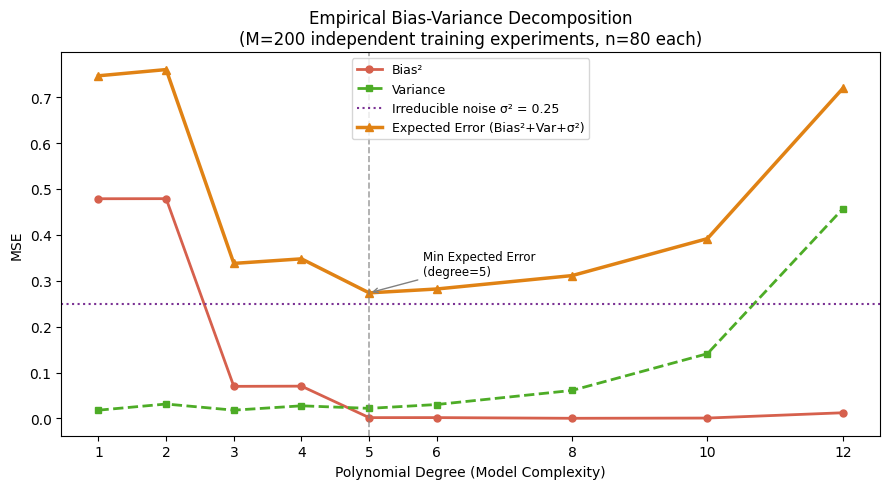

Saved: bias_variance_decomposition.png


In [14]:
degrees_d = [r["degree"] for r in decomp_results]
bias2_d   = [r["bias2"]  for r in decomp_results]
var_d     = [r["variance"] for r in decomp_results]
noise_d   = [r["noise"]  for r in decomp_results]
exp_d     = [r["expected_error"] for r in decomp_results]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(degrees_d, bias2_d,  color=C_BIAS2,    lw=2, ls="-",
        marker="o", ms=5, label="Bias²")
ax.plot(degrees_d, var_d,    color=C_VAR,      lw=2, ls="--",
        marker="s", ms=5, label="Variance")
ax.axhline(NOISE_STD**2,     color=C_NOISE,    lw=1.5, ls=":",
           label=f"Irreducible noise σ² = {NOISE_STD**2:.2f}")
ax.plot(degrees_d, exp_d,    color=C_EXPECTED, lw=2.5, ls="-",
        marker="^", ms=6, label="Expected Error (Bias²+Var+σ²)")

# Annotate the minimum Expected Error degree
min_exp = min(exp_d)
ax.axvline(best_degree_decomp, color="grey", ls="--", lw=1.2, alpha=0.7)
ax.annotate(
    f"Min Expected Error\n(degree={best_degree_decomp})",
    xy=(best_degree_decomp, min_exp),
    xytext=(best_degree_decomp + 0.8, min_exp + 0.04),
    fontsize=8.5,
    arrowprops=dict(arrowstyle="->", color="grey"),
)

ax.set_xlabel("Polynomial Degree (Model Complexity)")
ax.set_ylabel("MSE")
ax.set_title(
    f"Empirical Bias-Variance Decomposition\n"
    f"(M={M_BOOTSTRAP} independent training experiments, n={N_DEV} each)"
)
ax.legend(fontsize=9)
ax.set_xticks(degrees_d)
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_IMAGES, "bias_variance_decomposition.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bias_variance_decomposition.png")

**How to read this chart:**
- **Bias²** (red-orange): High at low degrees (model too rigid), decreases as complexity grows.
- **Variance** (green): Low at low degrees, increases sharply at high degrees (model too sensitive to training data).
- **Irreducible noise** (purple, horizontal): Constant. No model can reduce this.
- **Expected Error** (orange): The sum of all three. The degree at the minimum of this curve is the empirically optimal complexity under this DGP.

The minimum of Expected Error is annotated. Note that it does **not** necessarily occur where Bias² = Variance — the true optimum depends on the specific rates at which each component changes with complexity.

---

## Section 9 — Model Selection with Cross-Validation (Experiment 1)

We now use our **development dataset** and K-fold cross-validation to select polynomial degree in a principled way.

### Experiment 1: Model Complexity

| | |
|---|---|
| **Question** | How does polynomial degree affect training error and CV error? |
| **Hypothesis** | Training MSE decreases monotonically; CV MSE shows a minimum at some intermediate degree. Actual shape to be observed. |
| **Independent variable** | Polynomial degree |
| **Controlled** | Development dataset, KFold (shuffle=True, random_state=RANDOM_SEED), neg_mean_squared_error scoring |
| **Data** | Development dataset only — no test set used |

In [15]:
kf = KFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

train_mse_by_degree = []
cv_mse_by_degree    = []
cv_std_by_degree    = []

for d in DEGREES:
    pipeline_d = make_poly_pipeline(degree=d)

    # Cross-validation estimate (development data only)
    cv_scores = cross_val_score(
        pipeline_d, X_dev, y_dev,
        cv=kf,
        scoring="neg_mean_squared_error"
    )
    cv_mse_by_degree.append(-cv_scores.mean())
    cv_std_by_degree.append(cv_scores.std())

    # Training MSE (for comparison — not used for selection)
    pipeline_d.fit(X_dev, y_dev)
    train_mse_by_degree.append(
        mean_squared_error(y_dev, pipeline_d.predict(X_dev))
    )

# Model selected by CV (correct method)
best_degree_cv  = DEGREES[int(np.argmin(cv_mse_by_degree))]
best_cv_mse     = min(cv_mse_by_degree)

# Model selected by training error (failure-case comparison)
best_degree_train = DEGREES[int(np.argmin(train_mse_by_degree))]

print("Experiment 1 Results — Model Complexity")
print(f"{'Degree':>6}  {'Train MSE':>10}  {'CV MSE':>10}  {'CV Std':>8}")
print("-" * 42)
for i, d in enumerate(DEGREES):
    marker = " ← CV best" if d == best_degree_cv else ""
    print(f"{d:>6}  {train_mse_by_degree[i]:>10.4f}  "
          f"{cv_mse_by_degree[i]:>10.4f}  "
          f"{cv_std_by_degree[i]:>8.4f}{marker}")

print()
print(f"Degree selected by CV (correct):             {best_degree_cv}")
print(f"Degree selected by training error (failure): {best_degree_train}")

Experiment 1 Results — Model Complexity
Degree   Train MSE      CV MSE    CV Std
------------------------------------------
     1      0.6037      0.6152    0.2564
     2      0.6030      0.6556    0.2765
     3      0.2418      0.2596    0.0681
     4      0.2345      0.2577    0.0778
     5      0.2010      0.2277    0.0773 ← CV best
     6      0.2009      0.2305    0.0783
     7      0.1995      0.2407    0.0927
     8      0.1986      0.2556    0.1040
     9      0.1941      0.2775    0.1055
    10      0.1938      0.2803    0.1048
    11      0.1899      0.2542    0.0995
    12      0.1897      0.2698    0.0945

Degree selected by CV (correct):             5
Degree selected by training error (failure): 12


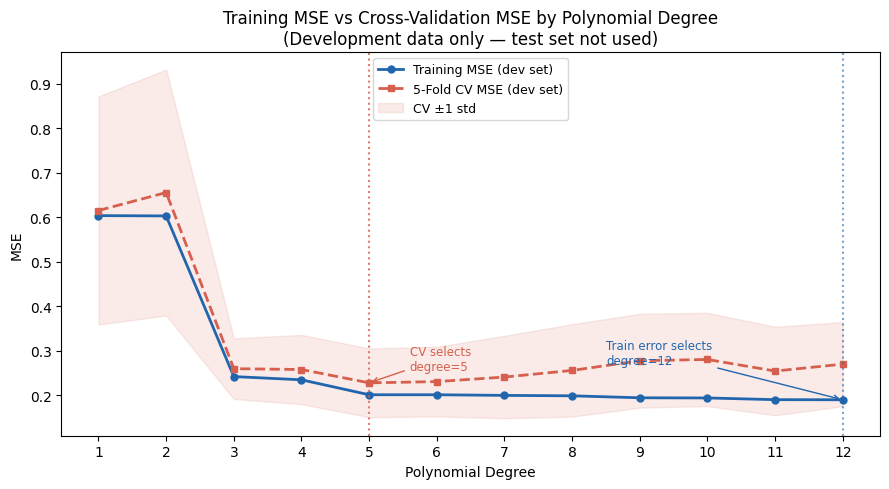

Saved: validation_curve.png


In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(DEGREES, train_mse_by_degree, color=C_TRAIN, lw=2,
        marker="o", ms=5, ls="-", label="Training MSE (dev set)")
ax.plot(DEGREES, cv_mse_by_degree, color=C_VAL, lw=2,
        marker="s", ms=5, ls="--", label=f"{N_CV_FOLDS}-Fold CV MSE (dev set)")

cv_std_arr = np.array(cv_std_by_degree)
cv_mse_arr = np.array(cv_mse_by_degree)
ax.fill_between(DEGREES,
                cv_mse_arr - cv_std_arr,
                cv_mse_arr + cv_std_arr,
                color=C_VAL, alpha=0.12, label="CV ±1 std")

ax.axvline(best_degree_cv, color=C_VAL, ls=":", lw=1.5, alpha=0.8)
ax.annotate(
    f"CV selects\ndegree={best_degree_cv}",
    xy=(best_degree_cv, best_cv_mse),
    xytext=(best_degree_cv + 0.6, best_cv_mse + 0.03),
    fontsize=8.5,
    color=C_VAL,
    arrowprops=dict(arrowstyle="->", color=C_VAL),
)

ax.axvline(best_degree_train, color=C_TRAIN, ls=":", lw=1.5, alpha=0.6)
ax.annotate(
    f"Train error selects\ndegree={best_degree_train}",
    xy=(best_degree_train,
        train_mse_by_degree[DEGREES.index(best_degree_train)]),
    xytext=(best_degree_train - 3.5,
            train_mse_by_degree[DEGREES.index(best_degree_train)] + 0.08),
    fontsize=8.5,
    color=C_TRAIN,
    arrowprops=dict(arrowstyle="->", color=C_TRAIN),
)

ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("MSE")
ax.set_title("Training MSE vs Cross-Validation MSE by Polynomial Degree\n"
             "(Development data only — test set not used)")
ax.legend(fontsize=9)
ax.set_xticks(DEGREES)
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_IMAGES, "validation_curve.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: validation_curve.png")

**Observed results:**

Training MSE decreased monotonically from degree 1 (0.6037) to degree 12 (0.1897). Selecting on training error would always choose the most complex model — in this case degree 12.

CV MSE tells a different story: it decreased from degree 1 (0.6152) to degree 5 (0.2277), then rose again as variance began to dominate. The CV-selected degree is **5**, which also matches the empirical decomposition's minimum Expected Error from Section 8.

Notice that CV MSE at degree 12 (0.2698) is substantially higher than at degree 5 (0.2277), confirming that the high-degree model generalises worse despite its lower training MSE. The standard deviation across folds also grows with degree — a secondary signal of increasing variance.

This is the **correct model selection methodology**: all decisions made on development data using cross-validation, with the test set untouched.

---

## Section 10 — Regularisation (Experiment 4)

Now we take the deliberately high-complexity model (degree `HIGH_DEGREE`) and use Ridge regularisation to move it back toward the bias-variance optimum. We select Ridge alpha via cross-validation on the development dataset.

### Experiment 4: Regularisation Strength

| | |
|---|---|
| **Question** | How does Ridge alpha control the bias-variance balance on the degree-12 model? |
| **Hypothesis** | Very small alpha → high variance; very large alpha → high bias; some intermediate alpha minimises CV MSE. Actual optimal alpha to be observed. |
| **Independent variable** | Ridge alpha (log scale) |
| **Controlled** | Degree fixed at HIGH_DEGREE, development dataset, same KFold |
| **Data** | Development dataset only |

In [17]:
ridge_cv_mse = []

for alpha in RIDGE_ALPHAS:
    pipe_ridge = make_poly_pipeline(degree=HIGH_DEGREE, ridge_alpha=alpha)
    scores = cross_val_score(
        pipe_ridge, X_dev, y_dev,
        cv=kf,
        scoring="neg_mean_squared_error"
    )
    ridge_cv_mse.append(-scores.mean())

best_alpha_idx = int(np.argmin(ridge_cv_mse))
best_alpha     = RIDGE_ALPHAS[best_alpha_idx]
best_ridge_cv_mse = ridge_cv_mse[best_alpha_idx]

print(f"Experiment 4 Results — Ridge Regularisation (degree={HIGH_DEGREE})")
print(f"Best Ridge alpha (CV on dev data): {best_alpha:.4f}")
print(f"CV MSE at best alpha:              {best_ridge_cv_mse:.4f}")
print(f"CV MSE for unregularised degree-{HIGH_DEGREE}: "
      f"{cv_mse_by_degree[DEGREES.index(HIGH_DEGREE)]:.4f}")
print(f"CV MSE for CV-selected degree ({best_degree_cv}): {best_cv_mse:.4f}")

Experiment 4 Results — Ridge Regularisation (degree=12)
Best Ridge alpha (CV on dev data): 0.1778
CV MSE at best alpha:              0.2712
CV MSE for unregularised degree-12: 0.2698
CV MSE for CV-selected degree (5): 0.2277


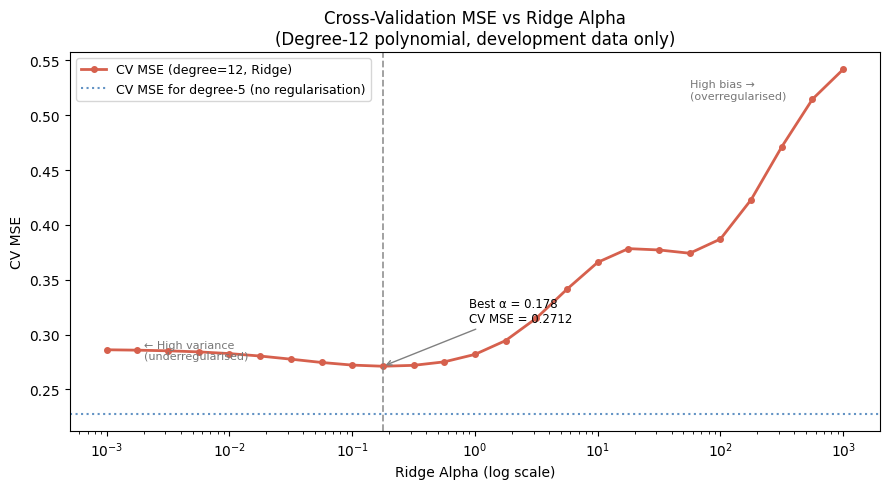

Saved: ridge_alpha.png


In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogx(RIDGE_ALPHAS, ridge_cv_mse, color=C_VAL, lw=2,
            marker="o", ms=4, label=f"CV MSE (degree={HIGH_DEGREE}, Ridge)")
ax.axvline(best_alpha, color="grey", ls="--", lw=1.3, alpha=0.8)
ax.annotate(
    f"Best α = {best_alpha:.3f}\nCV MSE = {best_ridge_cv_mse:.4f}",
    xy=(best_alpha, best_ridge_cv_mse),
    xytext=(best_alpha * 5, best_ridge_cv_mse + 0.04),
    fontsize=8.5,
    arrowprops=dict(arrowstyle="->", color="grey"),
)
ax.axhline(best_cv_mse, color=C_TRAIN, ls=":", lw=1.5, alpha=0.7,
           label=f"CV MSE for degree-{best_degree_cv} (no regularisation)")

ax.annotate("← High variance\n(underregularised)",
            xy=(RIDGE_ALPHAS[2], ridge_cv_mse[2]),
            xytext=(RIDGE_ALPHAS[0] * 2, ridge_cv_mse[0] * 0.97),
            fontsize=8, color="#777")
ax.annotate("High bias →\n(overregularised)",
            xy=(RIDGE_ALPHAS[-4], ridge_cv_mse[-4]),
            xytext=(RIDGE_ALPHAS[-6], ridge_cv_mse[-1] * 0.95),
            fontsize=8, color="#777")

ax.set_xlabel("Ridge Alpha (log scale)")
ax.set_ylabel("CV MSE")
ax.set_title(f"Cross-Validation MSE vs Ridge Alpha\n"
             f"(Degree-{HIGH_DEGREE} polynomial, development data only)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_IMAGES, "ridge_alpha.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ridge_alpha.png")

**How to read this chart:**

At very small alpha, the degree-12 model is effectively unregularised — high CV MSE due to high variance. As alpha increases, Ridge shrinks the polynomial coefficients, producing smoother fits and reducing variance. At the optimal alpha (0.1778), CV MSE reaches 0.2712.

The dashed horizontal line shows the degree-5 CV MSE (0.2277) — the benchmark from degree selection. The best Ridge-regularised degree-12 model (0.2712) does not match it: choosing the right complexity (degree 5) is more effective than regularising an over-complex model (degree 12) in this case.

**Why the CV gap is small between regularised and unregularised degree-12:** 5-fold CV on 80 samples already reveals the degree-12 model’s variance by measuring performance on unseen validation folds — CV exposes the variance, it does not constrain it. Ridge further constrains coefficient magnitudes, which matters most for predictions far from the training points — an effect that becomes more visible on larger test sets. Both the regularised and unregularised degree-12 models score similarly on CV because CV makes the variance observable regardless of whether the model is regularised.

The lesson: regularisation and complexity control are complementary tools. Cross-validation guides both.

---

## Section 11 — Effect of Training Data Size (Experiment 3)

More data generally helps a high-variance model generalise better. Here we measure this effect empirically on the degree-`HIGH_DEGREE` model.

**Methodology:** For each training sample size and repetition we use `numpy.random.SeedSequence` to spawn two independent, non-overlapping child RNG streams — one for the training dataset and one for the evaluation dataset. A single master `SeedSequence` (seeded with `EXP3_MASTER_SEED`) is declared once; child seeds are derived deterministically from `(role_id, size_index, repetition_index)` triples, guaranteeing that no two datasets ever share an RNG stream regardless of the arithmetic values of sample size or repetition index. We then report mean and standard deviation of evaluation MSE across repetitions.

> The **final test set** (`X_test`, `y_test`) is **not used here**. Each repetition uses its own independently generated evaluation dataset. The final test set remains locked until Section 12.

### Experiment 3: Training Data Size

| | |
|---|---|
| **Question** | Does more training data reduce the generalisation error of a high-complexity model? |
| **Hypothesis** | To be determined from observed results. |
| **Independent variable** | Training sample size |
| **Controlled** | Degree=HIGH_DEGREE, same DGP, R_REPEATS repeats per size |
| **Evaluation** | Independent evaluation dataset per repetition (not the final test set) |

In [19]:
# ── Experiment 3 RNG design ──────────────────────────────────────────────────
# We use numpy SeedSequence to spawn independent child RNG streams.
# A master SeedSequence is created once; child sequences are derived from
# a (role_id, size_index, rep_index) triple so every (dataset, role) pair
# receives a unique, non-overlapping random stream with no arithmetic collisions.
#
# role_id=0 → training dataset
# role_id=1 → evaluation dataset
#
# This guarantees:
#   - training and evaluation streams are always disjoint
#   - streams are identical across runs (deterministic)
#   - no two (role, n, r) triples ever share an integer seed

EXP3_MASTER_SEED = 8000  # declared constant; outside all other seed ranges

# Pre-generate all child integer seeds and verify uniqueness
_ss = np.random.SeedSequence(EXP3_MASTER_SEED)
_child_seeds = {}
for _si, _n in enumerate(SAMPLE_SIZES):
    for _r in range(R_REPEATS):
        for _role in (0, 1):  # 0=train, 1=eval
            _key = (_role, _si, _r)
            # spawn returns a list; take first and convert to 32-bit seed
            _child_seeds[_key] = _ss.spawn(1)[0].generate_state(1)[0]

# Verify all generated seeds are unique
all_seeds = list(_child_seeds.values())
assert len(all_seeds) == len(set(all_seeds)), (
    f"Seed collision detected! Expected {len(all_seeds)} unique seeds, "
    f"got {len(set(all_seeds))}."
)
print(f"Experiment 3 RNG: {len(all_seeds)} unique child seeds verified "
      f"(SeedSequence master={EXP3_MASTER_SEED}).")
print(f"  role 0 = training, role 1 = evaluation")
print(f"  No arithmetic seed formula — streams are disjoint by construction.")
print()

print(f"Running Experiment 3: Training Data Size (degree={HIGH_DEGREE})")
print(f"  Sample sizes: {SAMPLE_SIZES}")
print(f"  Repetitions per size: {R_REPEATS}")
print()

size_results = []

t0 = time.time()

# Re-spawn cleanly for actual use (same master seed → same streams)
_ss2 = np.random.SeedSequence(EXP3_MASTER_SEED)
# Build a lookup: (size_index, rep_index, role_id) → Generator
_gen = {}
for _si in range(len(SAMPLE_SIZES)):
    for _r in range(R_REPEATS):
        for _role in (0, 1):
            _child_ss = _ss2.spawn(1)[0]
            _gen[(_si, _r, _role)] = np.random.default_rng(_child_ss)

for si, n in enumerate(SAMPLE_SIZES):
    eval_mses = []
    for r in range(R_REPEATS):
        rng_train = _gen[(si, r, 0)]
        rng_eval  = _gen[(si, r, 1)]

        X_tr = rng_train.uniform(X_MIN, X_MAX, n).reshape(-1, 1)
        y_tr = true_function(X_tr.ravel()) + rng_train.normal(0, NOISE_STD, n)

        X_ev = rng_eval.uniform(X_MIN, X_MAX, 300).reshape(-1, 1)
        y_ev = true_function(X_ev.ravel()) + rng_eval.normal(0, NOISE_STD, 300)

        model_r = make_poly_pipeline(degree=HIGH_DEGREE)
        model_r.fit(X_tr, y_tr)
        mse_r = mean_squared_error(y_ev, model_r.predict(X_ev))
        eval_mses.append(mse_r)

    size_results.append({
        "n": n,
        "mean_mse": np.mean(eval_mses),
        "std_mse":  np.std(eval_mses),
    })

elapsed = time.time() - t0
print(f"Completed in {elapsed:.1f} seconds.")
print()
print(f"Results — degree={HIGH_DEGREE}, repeated-simulation evaluation MSE")
print(f"{'n_train':>8}  {'Mean MSE':>10}  {'Std MSE':>10}")
print("-" * 32)
for sr in size_results:
    print(f"{sr['n']:>8}  {sr['mean_mse']:>10.4f}  {sr['std_mse']:>10.4f}")


Experiment 3 RNG: 500 unique child seeds verified (SeedSequence master=8000).
  role 0 = training, role 1 = evaluation
  No arithmetic seed formula — streams are disjoint by construction.

Running Experiment 3: Training Data Size (degree=12)
  Sample sizes: [20, 40, 80, 150, 300]
  Repetitions per size: 50



Completed in 0.9 seconds.

Results — degree=12, repeated-simulation evaluation MSE
 n_train    Mean MSE     Std MSE
--------------------------------
      20  108364.3635  543863.0783
      40    544.1126   3728.6065
      80      0.3633      0.2479
     150      0.2791      0.0244
     300      0.2638      0.0212


Numerical blow-up detected at n=[20, 40].
  A degree-12 polynomial has 12 coefficients.
  With n << 12 training points the design matrix is
  near-rank-deficient, producing astronomically large predictions.
  This demonstrates why high-complexity models require sufficient data.
  Plotting only numerically stable sizes for readability.



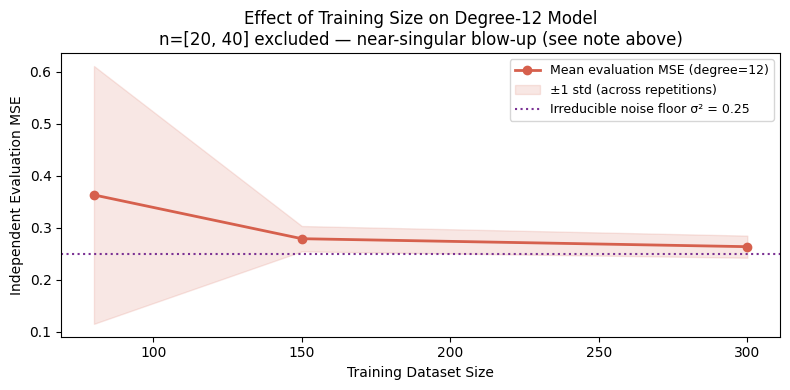

Saved: sample_size_effect.png


In [20]:
ns        = [sr["n"]        for sr in size_results]
mean_mses = [sr["mean_mse"] for sr in size_results]
std_mses  = [sr["std_mse"]  for sr in size_results]

# Identify sizes that produced numerical blow-up.
# A degree-12 polynomial has 12 free parameters. When n is much smaller
# than the number of parameters, the design matrix is near-singular and
# LinearRegression produces numerically unstable predictions.
# This is itself an educational result: very small datasets cannot support
# high-degree models without regularisation.
BLOWUP_THRESHOLD = 10.0
blown_up = [n for n, m in zip(ns, mean_mses) if m > BLOWUP_THRESHOLD]
stable   = [(n, m, s) for n, m, s in zip(ns, mean_mses, std_mses)
             if m <= BLOWUP_THRESHOLD]

if blown_up:
    print(f"Numerical blow-up detected at n={blown_up}.")
    print(f"  A degree-{HIGH_DEGREE} polynomial has {HIGH_DEGREE} coefficients.")
    print(f"  With n << {HIGH_DEGREE} training points the design matrix is")
    print(f"  near-rank-deficient, producing astronomically large predictions.")
    print(f"  This demonstrates why high-complexity models require sufficient data.")
    print(f"  Plotting only numerically stable sizes for readability.")
    print()

if stable:
    ns_s, m_s, std_s = zip(*stable)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(ns_s, m_s, color=C_VAL, lw=2, marker="o", ms=6,
            label=f"Mean evaluation MSE (degree={HIGH_DEGREE})")
    ax.fill_between(ns_s,
                    np.array(m_s) - np.array(std_s),
                    np.array(m_s) + np.array(std_s),
                    color=C_VAL, alpha=0.15, label="±1 std (across repetitions)")
    ax.axhline(NOISE_STD**2, color=C_NOISE, ls=":", lw=1.5,
               label=f"Irreducible noise floor σ² = {NOISE_STD**2:.2f}")
    if blown_up:
        subtitle = f"n={blown_up} excluded — near-singular blow-up (see note above)"
    else:
        subtitle = f"{R_REPEATS} independent repetitions per size — not the final test set"
    ax.set_xlabel("Training Dataset Size")
    ax.set_ylabel("Independent Evaluation MSE")
    ax.set_title(
        f"Effect of Training Size on Degree-{HIGH_DEGREE} Model\n{subtitle}"
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(ASSETS_IMAGES, "sample_size_effect.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: sample_size_effect.png")

**What to notice:**

At very small training sizes (n=20, n=40), fitting a degree-12 polynomial produces numerical blow-up — the design matrix has more columns than rows, making the system rank-deficient. `LinearRegression` (least squares via SVD) produces technically valid but astronomically large predictions. This is itself an educational result: **a high-complexity model without regularisation is unusable when training data is insufficient relative to the number of parameters**.

For n=80 and above, the model stabilises. The chart shows that as training size grows, mean evaluation MSE and its variability both decrease, approaching but not reaching the irreducible noise floor σ² = 0.25. This confirms the theoretical expectation: more data reduces variance, but cannot eliminate irreducible noise.

---

## Section 12 — Final Model Evaluation

All model-selection decisions are now complete:

1. **Selected degree**: `best_degree_cv` (chosen by CV on development data)
2. **No additional tuning** based on test-set results.

We now:
1. Freeze the model configuration.
2. Generate the final test set using `TEST_SEED` (independent of all development work).
3. Retrain the selected model on the **full development dataset**.
4. Evaluate **exactly once** on the final test set.
5. Report the result.

> If the final test MSE is unexpectedly high, we report and analyse it — we do **not** go back and change the model based on this result. The test set has been used; it cannot be reused for model selection.

In [21]:
# ── Step 1: Freeze the selected configuration ──────────────────────────────
print("=" * 55)
print("FINAL MODEL SELECTION SUMMARY")
print("=" * 55)
print(f"Selected degree (CV on dev data): {best_degree_cv}")
print(f"CV MSE estimate:                  {best_cv_mse:.4f}")
print()
print("Model configuration is now frozen.")
print("Generating final test set...")

# ── Step 2: Generate final test set (independent seed) ─────────────────────
X_test, y_test = generate_dataset(N_TEST, seed=TEST_SEED)
print(f"Final test set generated: n={N_TEST}, seed={TEST_SEED}")
print()

# ── Step 3: Retrain on full development dataset ────────────────────────────
final_model = make_poly_pipeline(degree=best_degree_cv)
final_model.fit(X_dev, y_dev)
print(f"Final model retrained on full development dataset (n={N_DEV}).")

# ── Step 4: Evaluate exactly once on the untouched final test set ──────────
final_test_mse = mean_squared_error(y_test, final_model.predict(X_test))
print()
print("=" * 55)
print("FINAL TEST RESULT (one-time evaluation)")
print("=" * 55)
print(f"Final test MSE (untouched test set): {final_test_mse:.4f}")
print(f"CV estimate (dev data):              {best_cv_mse:.4f}")
print(f"Irreducible noise floor σ²:          {NOISE_STD**2:.4f}")
print()
print("The final test set has been used. It will not be consulted again.")

FINAL MODEL SELECTION SUMMARY
Selected degree (CV on dev data): 5
CV MSE estimate:                  0.2277

Model configuration is now frozen.
Generating final test set...
Final test set generated: n=300, seed=999

Final model retrained on full development dataset (n=80).

FINAL TEST RESULT (one-time evaluation)
Final test MSE (untouched test set): 0.2908
CV estimate (dev data):              0.2277
Irreducible noise floor σ²:          0.2500

The final test set has been used. It will not be consulted again.


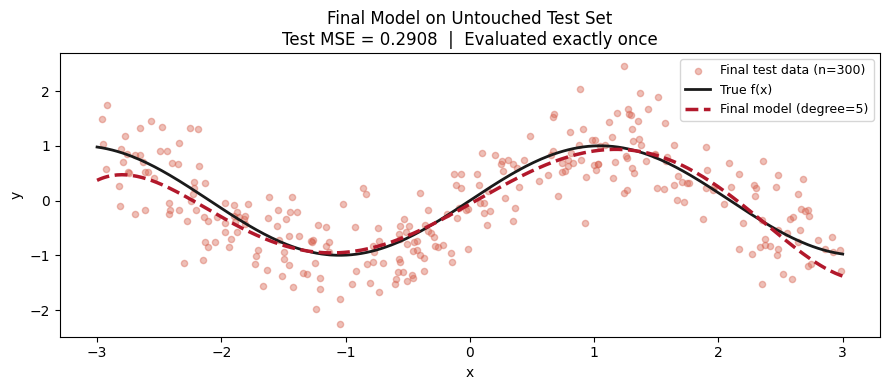

Saved: final_test_evaluation.png


In [22]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(X_test.ravel(), y_test, s=20, alpha=0.4,
           color=C_VAL, label=f"Final test data (n={N_TEST})")
ax.plot(X_eval.ravel(), f_eval, color=C_TRUE, lw=2,
        label="True f(x)")
ax.plot(X_eval.ravel(), final_model.predict(X_eval),
        color=C_PRED, lw=2.5, ls="--",
        label=f"Final model (degree={best_degree_cv})")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(
    f"Final Model on Untouched Test Set\n"
    f"Test MSE = {final_test_mse:.4f}  |  "
    f"Evaluated exactly once"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_IMAGES, "final_test_evaluation.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: final_test_evaluation.png")

---

## Section 13 — Failure Cases and Edge Cases

### Failure Case 1: Choosing Model Complexity by Training Error

We already have all the data we need from Experiment 1 to demonstrate this failure mode.

In [23]:
print("Failure Case 1: Training-Error-Based Model Selection")
print("=" * 50)
print()
print(f"Degree selected by TRAINING MSE:            {best_degree_train}")
print(f"Training MSE at degree {best_degree_train}:              "
      f"{train_mse_by_degree[DEGREES.index(best_degree_train)]:.4f}")
print(f"CV MSE at degree {best_degree_train} (actual generalisation estimate): "
      f"{cv_mse_by_degree[DEGREES.index(best_degree_train)]:.4f}")
print()
print(f"Degree selected by CROSS-VALIDATION:        {best_degree_cv}")
print(f"CV MSE at degree {best_degree_cv}:                "
      f"{best_cv_mse:.4f}")
print()
print("Why training error fails:")
print("  Training MSE measures how well the model memorised the")
print("  training data, not how well it generalises. A polynomial")
print("  of sufficiently high degree can interpolate any finite")
print("  dataset exactly, achieving near-zero training MSE while")
print("  predicting poorly on new data.")
print()
print("  Training MSE is a biased estimator of generalisation error:")
print("  it is always optimistic (too low), and more so for complex models.")

Failure Case 1: Training-Error-Based Model Selection

Degree selected by TRAINING MSE:            12
Training MSE at degree 12:              0.1897
CV MSE at degree 12 (actual generalisation estimate): 0.2698

Degree selected by CROSS-VALIDATION:        5
CV MSE at degree 5:                0.2277

Why training error fails:
  Training MSE measures how well the model memorised the
  training data, not how well it generalises. A polynomial
  of sufficiently high degree can interpolate any finite
  dataset exactly, achieving near-zero training MSE while
  predicting poorly on new data.

  Training MSE is a biased estimator of generalisation error:
  it is always optimistic (too low), and more so for complex models.


### Failure Case 2: Repeated Test-Set Use During Model Selection

We explain this failure mode conceptually. A direct code demonstration would require many outer repetitions and would itself require a meta-test set — which illustrates the point: every level of evaluation eventually needs its own held-out data.

In [24]:
print("Failure Case 2: Repeated Test-Set Use for Model Selection")
print("=" * 57)
print()
print("Incorrect workflow:")
print("  For each candidate degree d:")
print("    1. Train model on development data.")
print("    2. Evaluate on the FINAL TEST SET.")
print("    3. Record test MSE.")
print("  Select the degree with the lowest test MSE.")
print("  Report that test MSE as the final generalisation estimate.")
print()
print("Why this fails (structurally):")
print("  Each evaluation on the test set uses the test data to make")
print("  a selection decision. The minimum of K test-set evaluations")
print("  is a biased estimator of true generalisation error — it exploits")
print("  random variation in the test sample in the same way training MSE")
print("  exploits random variation in the training sample.")
print("  Once the test set participates in selection, its reported error")
print("  is no longer an unbiased final evaluation of the selection procedure.")
print("  Quantifying the selection-induced optimism requires repeated")
print("  selection/evaluation experiments — a single run only illustrates")
print("  that the selected configuration can change.")
print()
print("Correct workflow (as implemented in this notebook):")
print("  development data")
print("    → cross-validation")
print("    → model selection")
print("    → retrain on full development data")
print("    → evaluate ONCE on the final test set")
print("    → report result")
print("    → never adjust model based on this result")
print()

# Illustrative simulation: what if we had used the test set to select degree?
print("Illustrative comparison — DO NOT do this in practice:")
test_mses_by_degree = []
for i, d in enumerate(DEGREES):
    pipe_d = make_poly_pipeline(degree=d)
    pipe_d.fit(X_dev, y_dev)
    test_mses_by_degree.append(
        mean_squared_error(y_test, pipe_d.predict(X_test))
    )

best_degree_test_selection = DEGREES[int(np.argmin(test_mses_by_degree))]
optimistic_mse = min(test_mses_by_degree)

print(f"  CV-based selection chose degree:          {best_degree_cv}")
print(f"  Test-set selection chose degree:          {best_degree_test_selection}")
print(f"  CV MSE for CV-selected degree:            {best_cv_mse:.4f}")
print(f"  CV MSE for test-selected degree:          "
      f"{cv_mse_by_degree[DEGREES.index(best_degree_test_selection)]:.4f}")
print(f"  Reported test MSE (test-selected model):  {optimistic_mse:.4f}")
print()
if best_degree_test_selection != best_degree_cv:
    print(f"  In this run the two methods disagree: test-set reuse changed the")
    print(f"  selected configuration from degree {best_degree_cv} to degree "
          f"{best_degree_test_selection}.")
    print(f"  Degree {best_degree_test_selection} has higher CV-estimated error "
          f"({cv_mse_by_degree[DEGREES.index(best_degree_test_selection)]:.4f} vs "
          f"{best_cv_mse:.4f}), indicating it is a weaker generaliser on")
    print(f"  average — but this comparison is across CV folds, not across")
    print(f"  independent test sets. A single run cannot estimate the magnitude")
    print(f"  of selection-induced optimism; it illustrates how test-set reuse")
    print(f"  can contaminate model selection and change the selected model.")
else:
    print(f"  In this run both methods selected degree {best_degree_cv}.")
    print(f"  Test-set reuse still contaminates the evaluation: the reported")
    print(f"  test MSE ({optimistic_mse:.4f}) reflects the minimum across")
    print(f"  {len(DEGREES)} evaluations of the same test set, not an unbiased")
    print(f"  estimate. The contamination is structural regardless of whether")
    print(f"  the selected degree happens to match the CV choice in a given run.")


Failure Case 2: Repeated Test-Set Use for Model Selection

Incorrect workflow:
  For each candidate degree d:
    1. Train model on development data.
    2. Evaluate on the FINAL TEST SET.
    3. Record test MSE.
  Select the degree with the lowest test MSE.
  Report that test MSE as the final generalisation estimate.

Why this fails (structurally):
  Each evaluation on the test set uses the test data to make
  a selection decision. The minimum of K test-set evaluations
  is a biased estimator of true generalisation error — it exploits
  random variation in the test sample in the same way training MSE
  exploits random variation in the training sample.
  Once the test set participates in selection, its reported error
  is no longer an unbiased final evaluation of the selection procedure.
  Quantifying the selection-induced optimism requires repeated
  selection/evaluation experiments — a single run only illustrates
  that the selected configuration can change.

Correct workflow (as imp

---

## Section 14 — Debugging Guide

| Symptom | Likely cause | How to inspect | How to fix |
|---|---|---|---|
| Training MSE is very low but CV MSE is high | Overfitting — high variance | Plot V5 (validation curve); compare train vs. CV MSE gap | Reduce model complexity, add regularisation, collect more data |
| Both training MSE and CV MSE are high | Underfitting — high bias | Plot V5; both curves plateau at a high value | Increase model complexity, add more features, try a more flexible model class |
| CV MSE is much lower than final test MSE | Test-set leakage or distribution shift | Check if test data was used during model selection; check if test distribution differs from training distribution | Ensure strict separation; use CV only for selection |
| `LinAlgWarning` from scikit-learn on high-degree polynomial | Near-singular design matrix | Print condition number of the polynomial feature matrix | Use Ridge instead of LinearRegression; reduce degree |
| CV score variance is very high across folds | Too few training samples for the number of CV folds, or high model variance | Reduce K or use repeated K-fold; check n_dev vs. degree | Use more data; reduce complexity; use Ridge |
| Decomposition Bias² and Variance values jump erratically | M too small for stable estimates | Plot decomposition with different M values | Increase M_BOOTSTRAP |
| Final test MSE is much higher than CV estimate | Possible distribution shift or unlucky test split | Examine the test data distribution vs. development distribution | This is informative — do not retune based on it |

---

## Section 15 — Production Reality

This notebook demonstrated the bias-variance trade-off on a clean synthetic problem. In production ML systems, several additional concerns apply.

**Data:** In production, you rarely have a known true function. You cannot compute exact bias or irreducible noise. You rely on cross-validation and held-out test sets — making disciplined data splitting even more important.

**Scale:** With millions of data points, a 5-fold CV over many hyperparameters can be expensive. Techniques like random search, Bayesian optimisation, or successive halving (scikit-learn's `HalvingGridSearchCV`) are used instead.

**Distribution shift:** A model trained and validated on historical data may encounter a different distribution at inference time. CV estimates do not catch this. Monitoring for data drift (e.g., comparing feature distributions over time) is a production necessity.

**Test-set discipline:** In production, the "test set" is often real-world deployment. The same principle applies: avoid using production observations to tune the model. Treat periodic evaluation on production data as a monitoring metric, not a tuning signal.

**Regularisation in pipelines:** In production pipelines, preprocessing steps (scalers, feature transformers) should always be fitted inside a `Pipeline` so that the CV fold sees only training-fold-fitted transformers. `PolynomialFeatures` does not learn statistics from the data, but `StandardScaler` does — fitting it on the whole dataset before CV introduces a subtle data leak.

**Model complexity in practice:** Polynomial degree is a pedagogical stand-in. In practice, complexity is controlled through:
- Decision tree depth
- Number of estimators and learning rate in gradient boosting
- Network width and depth in neural networks
- Regularisation strength in all linear models

The bias-variance framework applies to all of them.

---

## Section 16 — Exercises

Work through these exercises to test and deepen your understanding. Hints are provided; do not look at solutions before attempting.

### Exercise 1 (Easy) — Change the Noise Level

Change `NOISE_STD` to `0.1` and rerun the notebook.

- How does the validation curve change?
- Does the CV-selected degree change? Why or why not?
- How does the decomposition chart change?

**Hint:** Lower noise means cleaner data. What happens to the bias-variance trade-off when the target signal is less obscured by noise?

---

### Exercise 2 (Medium) — Extend the Degree Range

Change `DEGREES` to `list(range(1, 20))` and update `DECOMP_DEGREES` accordingly.

- Does the CV MSE continue to increase monotonically beyond degree 12, or does it plateau?
- What happens to the bias-variance decomposition at degree 15–18?

**Hint:** At very high degrees with only 80 training points, numerical issues may appear. Check for warnings.

---

### Exercise 3 (Medium) — Lasso vs. Ridge

Replace `Ridge` with `Lasso` (from `sklearn.linear_model`) in the regularisation experiment.

- How does the CV MSE vs. alpha curve differ between Ridge and Lasso?
- Lasso can produce sparse solutions (many zero coefficients). Does it do so here? Check `model[-1].coef_` after fitting the best Lasso model.

**Hint:** Lasso uses an L1 penalty (`|w|`) rather than Ridge's L2 (`w²`). For polynomial features with a smooth true function, Ridge is typically a better choice — observe whether the data confirm this.

---

### Exercise 4 (Harder) — Increase M and Measure Stability

Run the empirical decomposition with `M_BOOTSTRAP = 50`, `200`, and `500`.

- How do the Bias² and Variance estimates change as M increases?
- At what M do the curves become stable enough to be educationally reliable?
- What does this tell you about using a small M in practice?

**Hint:** Save the decomposition results for each M value and plot them on the same axes for comparison. The "true" values are approximated more closely as M → ∞.

---

## Section 17 — Summary

### WHAT

**Bias** is the systematic error of a model — how far its average prediction is from the true function, averaged over all possible training datasets. High bias means the model is too rigid to capture the true pattern.

**Variance** is the sensitivity of a model to the specific training dataset used. High variance means the model memorises the training data (including noise) rather than learning the underlying pattern.

### WHY

The decomposition $\text{E}[(y - \hat{f})^2] = \text{Bias}^2 + \text{Variance} + \sigma^2$ shows that expected prediction error has three components. Bias and variance move in opposite directions as model complexity changes — reducing one typically increases the other. The irreducible noise $\sigma^2$ cannot be eliminated by any model.

### HOW

- **Detect underfitting**: Both training and CV MSE are high. The model is too simple.
- **Detect overfitting**: Training MSE is low; CV MSE is high. The model is too complex.
- **Fix underfitting**: Increase complexity, add features, try a more flexible model.
- **Fix overfitting**: Add regularisation, collect more data, reduce complexity.
- **Select complexity**: Use cross-validation on development data — never the final test set.
- **Evaluate**: Use the final test set exactly once, after all model-selection decisions.

### What the Experiments Taught

- **Experiment 1**: Training MSE is an unreliable model-selection criterion — it always favours the most complex model. Cross-validation reveals the trade-off.
- **Experiment 2**: The empirical decomposition confirms that Bias² decreases and Variance increases with polynomial degree. The minimum Expected Error occurs at a specific complexity level — not necessarily where Bias² = Variance.
- **Experiment 3**: More training data reduces the generalisation error of high-complexity models, but diminishing returns set in well above the irreducible noise floor.
- **Experiment 4**: Ridge on the degree-12 model selected alpha=0.1778 (CV MSE 0.2712), marginally worse than the unregularised baseline (0.2698) and well above the degree-5 optimum (0.2277). Choosing the right complexity was more effective than regularising an over-complex model.

### Important Failure Modes

1. Selecting model complexity by training error → always overfits.
2. Using the final test set repeatedly for selection → optimistically biased evaluation.

### When to Apply This

Every supervised learning problem involves this trade-off. Apply this framework whenever you observe a large gap between training and validation performance, or when a simpler model outperforms a more complex one on held-out data.

### When Complexity Reduction Is Not Enough

If both training and validation errors are high regardless of complexity, the problem may not be in the model — it may be in the features, the data volume, or the irreducible difficulty of the task.

### Final Mental Model

> A model that memorises is useless on new data. A model that oversimplifies is useless everywhere. The goal is to find the complexity where the model generalises — and cross-validation is how you find it.